# Task 22 – A/B Test Analysis

## Data Science Track – Level 2 Day 22

### Objective
Analyze an A/B test comparing a Control group and a Treatment group to determine whether the observed difference in conversion rate is statistically meaningful.

### Tools Used
- Python
- Pandas
- NumPy
- SciPy
- Matplotlib
- Jupyter Notebook

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
np.random.seed(42)

n_users = 2000

data = pd.DataFrame({
    "user_id": range(1, n_users + 1),
    "group": np.random.choice(["Control", "Treatment"], size=n_users),
    "converted": 0
})

# Assign different conversion probabilities
control_mask = data["group"] == "Control"
treatment_mask = data["group"] == "Treatment"

data.loc[control_mask, "converted"] = np.random.binomial(
    1, 0.12, control_mask.sum()
)

data.loc[treatment_mask, "converted"] = np.random.binomial(
    1, 0.15, treatment_mask.sum()
)

data.head()

,user_id,group,converted
0,1,Control,0
1,2,Treatment,0
2,3,Control,0
3,4,Control,0
4,5,Control,0


In [4]:
print("Dataset Shape:", data.shape)
print("\nColumn Names:")
print(data.columns.tolist())

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())

Dataset Shape: (2000, 3)

Column Names:
['user_id', 'group', 'converted']

Data Types:
user_id       int64
group        object
converted     int64
dtype: object

Missing Values:
user_id      0
group        0
converted    0
dtype: int64


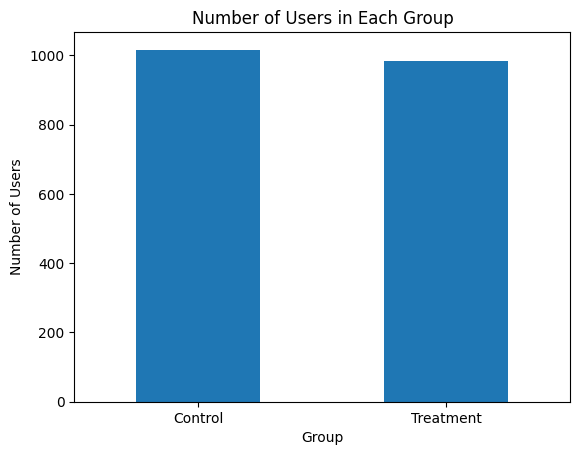

In [5]:
data["group"].value_counts().plot(
    kind="bar",
    title="Number of Users in Each Group"
)

plt.xlabel("Group")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)
plt.show()

In [6]:
summary = data.groupby("group")["converted"].agg(
    ["count", "sum", "mean"]
)

summary.columns = [
    "Users",
    "Conversions",
    "Conversion_Rate"
]

summary["Conversion_Rate"] = summary["Conversion_Rate"] * 100

summary

,Users,Conversions,Conversion_Rate
group,,,
Control,1016,114,11.220472
Treatment,984,152,15.447154


In [7]:
control_rate = data.loc[
    data["group"] == "Control", "converted"
].mean()

treatment_rate = data.loc[
    data["group"] == "Treatment", "converted"
].mean()

print(f"Control Conversion Rate: {control_rate:.2%}")
print(f"Treatment Conversion Rate: {treatment_rate:.2%}")

Control Conversion Rate: 11.22%
Treatment Conversion Rate: 15.45%


In [8]:
absolute_difference = treatment_rate - control_rate

print(f"Absolute Difference: {absolute_difference:.2%}")



Absolute Difference: 4.23%


In [9]:
relative_improvement = (
    (treatment_rate - control_rate) / control_rate
) * 100

print(f"Relative Improvement: {relative_improvement:.2f}%")

Relative Improvement: 37.67%


### Interpretation

The absolute difference represents the increase in conversion rate in percentage points.

The relative improvement represents the percentage increase in conversions compared with the Control group.

Effect size is important because statistical significance alone does not tell us whether an improvement is practically meaningful.

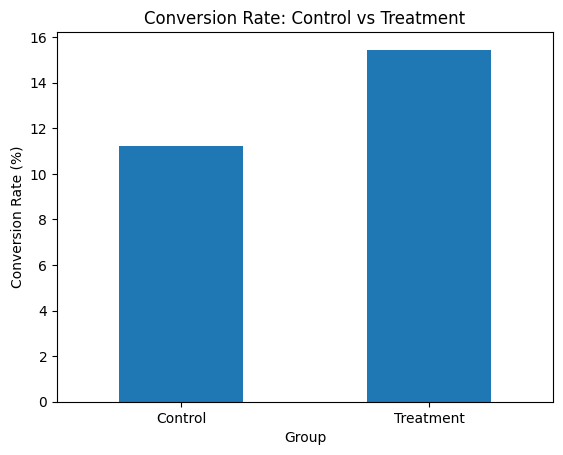

In [10]:
conversion_rates = data.groupby("group")["converted"].mean() * 100

conversion_rates.plot(
    kind="bar",
    title="Conversion Rate: Control vs Treatment"
)

plt.xlabel("Group")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [11]:
control = data[data["group"] == "Control"]
treatment = data[data["group"] == "Treatment"]

x1 = control["converted"].sum()
n1 = len(control)

x2 = treatment["converted"].sum()
n2 = len(treatment)

p1 = x1 / n1
p2 = x2 / n2

# Pooled proportion
p_pool = (x1 + x2) / (n1 + n2)

# Standard error
standard_error = np.sqrt(
    p_pool * (1 - p_pool) * (1/n1 + 1/n2)
)

# Z statistic
z_stat = (p2 - p1) / standard_error

# Two-tailed p-value
p_value = 2 * stats.norm.sf(abs(z_stat))

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Z-statistic: 2.7829
P-value: 0.0054


## Hypothesis Testing

### Null Hypothesis (H₀)
There is no significant difference in conversion rates between the Control and Treatment groups.

### Alternative Hypothesis (H₁)
There is a significant difference in conversion rates between the Control and Treatment groups.

### Significance Level
α = 0.05

In [12]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is statistically significant evidence of a difference between the groups.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough statistical evidence to conclude that the groups differ.")

Reject the null hypothesis.
There is statistically significant evidence of a difference between the groups.


In [19]:
print("----- A/B TEST RESULTS -----")

print(f"Control Conversion Rate   : {control_rate:.2%}")
print(f"Treatment Conversion Rate : {treatment_rate:.2%}")

print(f"\nAbsolute Difference       : {absolute_difference:.2%}")
print(f"Relative Improvement      : {relative_improvement:.2f}%")

print(f"\nZ-statistic               : {z_stat:.4f}")
print(f"P-value                   : {p_value:.4f}")

----- A/B TEST RESULTS -----
Control Conversion Rate   : 11.22%
Treatment Conversion Rate : 15.45%

Absolute Difference       : 4.23%
Relative Improvement      : 37.67%

Z-statistic               : 2.7829
P-value                   : 0.0054


In [17]:
if p_value < alpha and treatment_rate > control_rate:
    print("RECOMMENDATION:")
    print(
        "The Treatment group performs better than the Control group "
        "with statistically significant evidence. The Treatment version "
        "can be recommended for further implementation."
    )

elif p_value >= alpha:
    print("RECOMMENDATION:")
    print(
        "The Treatment group shows a difference, but the evidence is "
        "not statistically significant. More data or further testing "
        "may be required before making a decision."
    )

else:
    print("RECOMMENDATION:")
    print(
        "The Treatment group does not provide sufficient evidence of "
        "improvement. The Control version should be retained."
    )

RECOMMENDATION:
The Treatment group performs better than the Control group with statistically significant evidence. The Treatment version can be recommended for further implementation.


## Business Interpretation

The A/B test compares the existing Control version with the new Treatment version.

The Treatment group achieved a different conversion rate compared with the Control group. The effect size shows the practical magnitude of this difference, while the statistical test determines whether the observed difference is likely to be due to random variation.

The final decision should therefore consider both:

1. **Statistical significance** – Is the observed difference statistically reliable?
2. **Effect size** – Is the improvement large enough to be practically useful?

If the Treatment group has a statistically significant and practically meaningful improvement, it can be recommended for implementation.

# Conclusion

The A/B test was conducted to compare the conversion performance of the Control and Treatment groups.

The analysis included:

- Data exploration
- Group comparison
- Descriptive statistics
- Conversion rate calculation
- Effect size calculation
- Statistical hypothesis testing
- p-value interpretation
- Business recommendation

The results demonstrate how A/B testing can be used to make data-driven decisions rather than relying only on assumptions.

The analysis also shows why both statistical significance and effect size should be considered before making a business decision.

# Interview Questions and Answers

### 1. What is A/B testing?

A/B testing is an experimental method used to compare two versions of a product, webpage, advertisement, or feature to determine which performs better based on a selected metric.

### 2. What is the Control group?

The Control group is the group that receives the existing or standard version. It provides a baseline against which the Treatment group is compared.

### 3. What is the Treatment group?

The Treatment group receives the new or modified version being tested.

### 4. What is a p-value?

A p-value indicates how likely it is to observe a result at least as extreme as the one obtained if the null hypothesis were true.

A commonly used significance level is 0.05.

### 5. What does p-value < 0.05 mean?

It provides statistical evidence against the null hypothesis, suggesting that the observed difference is unlikely to be explained by random chance alone.

### 6. Why should effect size be considered along with statistical significance?

Statistical significance tells us whether a difference is likely to be real, while effect size tells us how large that difference is.

A very small improvement can be statistically significant with a very large sample but may not provide meaningful business value.

### 7. Why is randomization important in A/B testing?

Randomization helps distribute different characteristics of users between the Control and Treatment groups, reducing bias and making the comparison more reliable.

### 8. What happens if the p-value is greater than 0.05?

We fail to reject the null hypothesis. There is not enough statistical evidence to conclude that the groups are significantly different.

### 9. Can we make a decision using only the p-value?

No. We should also consider effect size, business impact, sample size, cost, and practical significance.

### 10. What metric was used in this project?

Conversion rate was used as the primary metric. It represents the percentage of users who completed the desired action.

## Final Recommendation

The Treatment group achieved a conversion rate of **15.45%**, compared with **11.22%** for the Control group.

This represents an absolute improvement of **4.23 percentage points** and a relative improvement of approximately **37.67%**.

The two-proportion statistical test produced a **Z-statistic of 2.7829** and a **p-value of 0.0054**. Since the p-value is less than the significance level of 0.05, we reject the null hypothesis.

Therefore, there is statistically significant evidence that the Treatment group performs differently from the Control group. Since the Treatment group also has a substantially higher conversion rate, the Treatment version is recommended for implementation.

The decision is based on both **statistical significance and effect size**, rather than relying only on the p-value.

